## Nonlinear Least-Squares with Python
In this section, we present a couple of nonlinear least-squares examples.
Let us first use an optimizer from Scipy. Then, we implement the Gauss-Newton method in our lecture to solve such examples.

### Example 1: Motivating example
We want to fit a nonlinear model $y = f(S;\beta) + \epsilon$ to a given data set, where $f(S;\beta) = \frac{\alpha S}{1 + S/k}$ with $\beta = (\alpha, k)$. 
The dataset we are using is "spawning_biomass", consisting of 15 data points.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../Data/spawning_biomass.csv") # Student needs to change the path to the data set. 
#print(df)
X_train  = df["Spawn biomass"].to_numpy()#.reshape(-1, 1)
y_train  = df["Number of Fish"].to_numpy() 
print(X_train)
print(y_train)

## Or type the dataset directly here.
#X_train = np.array([59.8, 61.4, 58.8, 44.1, 26.4, 24.2, 22.8, 18.9, 19.4, 20.5, 21.5, 21.0, 16.5, 15.2, 18.0]) #.reshape(-1,1)
#y_train = np.array([125, 107, 136, 97, 104, 97, 84, 56, 59, 69, 86, 70, 63, 32, 83])
#print(X_train)
#print(y_train)

[59.8 61.4 68.8 44.1 24.4 22.2 18.9 19.4 20.5 21.  21.  16.5 16.5 15.2
 18. ]
[125 107 136 107 194  97  56  94  69  66  70  63  63  32  33]


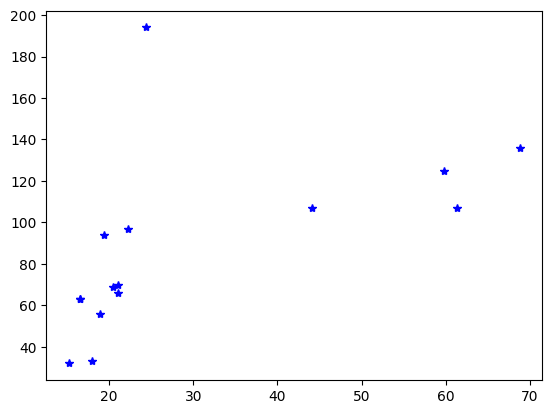

In [2]:
from matplotlib import pyplot as plt
plt.plot(X_train, y_train, 'b*', label='data')


In [3]:
# Define our nonlinear model
def nl_model(S, alpha, k):
    return alpha*S/(1 + S/k)

In [4]:
# Call the curve_fit routine from Scipy.
from scipy.optimize import curve_fit
par_opt, par_cov = curve_fit(nl_model, X_train, y_train)
print(par_opt)

[ 6.44556919 29.08673722]


In [5]:
# Example one in the slides
def nl_model2(x, beta0, beta1):
    return beta0*np.exp(x/beta1)

In [6]:
import numpy as np
X_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,\
                    4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, 8, 8])
y_train = np.array([0.169, 0.164, 0.210, 0.215, 0.183, 0.181, 0.188, 0.229,\
                    0.268, 0.202, 0.193, 0.262, 0.215, 0.285, 0.313, 0.222, 0.225,\
                    0.326, 0.283, 0.374, 0.406, 0.304, 0.284, 0.463, 0.456, 0.598, 0.618,\
                    0.475, 0.425, 0.554, 0.810, 1.011, 0.999, 0.751, 0.742, 1.273, 1.300,\
                    1.612, 1.588, 1.225, 1.208])

In [7]:
# Call the curve_fit routine from Scipy for Example 1 in the slides.
from scipy.optimize import curve_fit
par_opt, par_cov = curve_fit(nl_model2, X_train, y_train)
print("The parameters: [beta0, beta1] = ", par_opt)

The parameters: [beta0, beta1] =  [0.16372089 3.76453932]


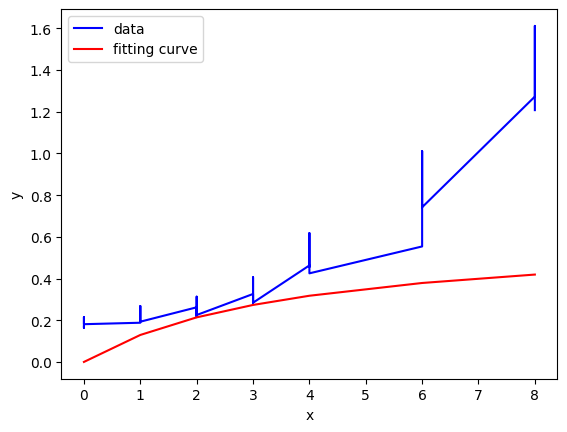

In [8]:
# Plot the result.
from matplotlib import pyplot as plt
plt.plot(X_train, y_train, 'b-', label='data')
plt.plot(X_train, nl_model(X_train, *par_opt), 'r-', label='fitting curve' )
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Example 2: Fitting an exponential model
We fit a nonlinear model $y = f(x;\beta) + \epsilon$ to a given dataset below, where $f(x;\beta) = \beta_0\cdot\exp(x/\beta_1)$.
In this example, we implement the Gauss-Newton method in the lecture note to solve the underlying nonlinear least-squares problem. But first, we solve it by "curve_fit" from Scipy.

In [9]:
import numpy as np
# We type data directly in Python. This is a RGR dataset (see Lecture 4)
x_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,\
                    4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, 8, 8])
y_train = np.array([0.169, 0.164, 0.210, 0.215, 0.183, 0.181, 0.188, 0.229,\
                    0.268, 0.202, 0.193, 0.262, 0.215, 0.285, 0.313, 0.222, 0.225,\
                    0.326, 0.283, 0.374, 0.406, 0.304, 0.284, 0.463, 0.456, 0.598, 0.618,\
                    0.475, 0.425, 0.554, 0.810, 1.011, 0.999, 0.751, 0.742, 1.273, 1.300,\
                    1.612, 1.588, 1.225, 1.208])

In [10]:
# Define the model
def my_model(x, b0, b1):
    return b0*np.exp(x/b1)

In [11]:
# First, we solve the nonlinear least-squares problem by the curve_fit in Scipy.
from scipy.optimize import curve_fit
par_opt, par_cov = curve_fit(my_model, x_train, y_train)
print(par_opt)

[0.16372089 3.76453932]


In [12]:
# Next, we implement the function and its Jacobian mapping.
def Fval(x, y, beta):
    return np.array( beta[0]*np.exp(x/beta[1]) - y)

def Jac(x, beta):
    return np.array([np.exp(x/beta[1]), -(beta[0]/beta[1]**2)*np.exp(x/beta[1])*x ])

In [13]:
# We implement the Gauss-Newton method here.
from numpy import linalg as la
def GN(Fx, Jac, x, y, beta0, maxiter = 100, tol = 1e-3):
    bet = beta0
    err  = 0
    for t in range(0, maxiter):
        Ft  = Fx(x, y, bet)
        Jt  = Jac(x, bet)
        St  = la.pinv( Jt.dot(Jt.T) )
        yt  = Jt.dot(Ft).T
        dt = St.dot(yt)
        bet = bet - dt
        err = la.norm(yt)
        print("Iteration: {0:2d}".format(t), "-- Error: {0:5.4e}".format(err))
        if err <= tol:
            print(">>> Convergence achieved!")
            break
    return bet, err, t

In [14]:
# We implement the Gauss-Newton method here, but now we use sklearn to solve the linear least-squares problem
from numpy import linalg as la
from sklearn.linear_model import LinearRegression
def GN2(Fx, Jac, x, y, beta0, maxiter = 100, tol = 1e-3):
    bet = beta0
    lin_reg = LinearRegression(fit_intercept=False)
    err  = 0
    for t in range(0, maxiter):
        Ft  = Fx(x, y, bet)
        Jt  = Jac(x, bet)
        yt  = Jt.dot(Ft).T
        lin_reg.fit(Jt.T, -Ft)
        dt  = lin_reg.coef_
        bet = bet + dt
        err = la.norm(yt)
        print("Iteration: {0:2d}".format(t), "-- Error: {0:5.4e}".format(err))
        if err <= tol:
            print(">>> Convergence achieved!")
            break
    return bet, err, t

In [15]:
# We run it.
beta0 = np.array([1, 2])
beta_best, err, n_it = GN(Fval, Jac, x_train, y_train, beta0)
print("\nParameters:", beta_best, "\nError: ", err, "\nNumber of Iterations: ", n_it)

beta_best2, err2, n_it2 = GN2(Fval, Jac, x_train, y_train, beta0)
print("\nParameters:", beta_best2, "\nError: ", err2, "\nNumber of Iterations: ", n_it2)

Iteration:  0 -- Error: 4.3734e+04
Iteration:  1 -- Error: 1.3142e+03
Iteration:  2 -- Error: 2.6061e+02
Iteration:  3 -- Error: 5.1467e+01
Iteration:  4 -- Error: 9.8034e+00
Iteration:  5 -- Error: 9.5526e-01
Iteration:  6 -- Error: 1.1868e-02
Iteration:  7 -- Error: 1.4007e-06
>>> Convergence achieved!

Parameters: [0.16372089 3.76453933] 
Error:  1.400680826889285e-06 
Number of Iterations:  7
Iteration:  0 -- Error: 4.3734e+04
Iteration:  1 -- Error: 1.3142e+03
Iteration:  2 -- Error: 2.6061e+02
Iteration:  3 -- Error: 5.1467e+01
Iteration:  4 -- Error: 9.8034e+00
Iteration:  5 -- Error: 9.5526e-01
Iteration:  6 -- Error: 1.1868e-02
Iteration:  7 -- Error: 1.4007e-06
>>> Convergence achieved!

Parameters: [0.16372089 3.76453933] 
Error:  1.400680826889285e-06 
Number of Iterations:  7


## Solve Example 1 by GN method

In [16]:
import numpy as np
X_train2 = np.array([59.8, 61.4, 58.8, 44.1, 26.4, 24.2, 22.8, 18.9, 19.4, 20.5, 21.5, 21.0, 16.5, 15.2, 18.0])
y_train2 = np.array([125, 107, 136, 97, 104, 97, 84, 56, 59, 69, 86, 70, 63, 32, 83])

def Fval2(S, y, beta):
    return np.array(beta[0]*S/(1.0+S/beta[1]) - y)

def Jac2(S, beta):
    return np.array([S/(1.0+S/beta[1]), beta[0]*(S/(beta[1]*(1.0+S/beta[1])))**2 ])

In [17]:
beta0 = [10, 10]
beta_best, err, n_it = GN(Fval2, Jac2, X_train2, y_train2, beta0)
print("\nParameters:", beta_best, "\nError: ", err, "\nNumber of Iterations: ", n_it)

Iteration:  0 -- Error: 2.0442e+03
Iteration:  1 -- Error: 2.6482e+04
Iteration:  2 -- Error: 3.6055e+03
Iteration:  3 -- Error: 1.7594e+03
Iteration:  4 -- Error: 7.9818e+01
Iteration:  5 -- Error: 6.6066e-01
Iteration:  6 -- Error: 5.5812e-03
Iteration:  7 -- Error: 1.6312e-04
>>> Convergence achieved!

Parameters: [ 5.75102425 33.15715473] 
Error:  0.00016311642880073108 
Number of Iterations:  7


## Example 1: Another Implementation of the Gauss-Newton method

In [18]:
import numpy as np
from numpy.linalg import norm
from numpy.linalg import lstsq

def gauss_newton(model_residual_eval, model_jacobian_eval,
                 X: np.ndarray, y: np.ndarray, beta0: np.ndarray, 
                  max_iter: int = 100, rtol: float = 1e-6, verbose: bool = True,
                ) -> tuple[np.ndarray, dict]:
    """
    This is another implementation of the Gauss-Newton method for nonlinear least squares: 
                           minimize 0.5 * ||r(beta)||_2^2,
    where r(beta) = y - varphi(beta; X).
    Uses the stable least-squares solve for the GN step:
        minimize_d ||J d + r||_2
      => d = argmin ||J d + r||_2  (solved via lstsq)
        beta_{k+1} = beta_k + d

    Stopping criterion: ||J^T r||_2 <= rtol * ||J^T r_0||_2

    Returns
    -------
    beta: (2,) array -- Estimated parameters.
    info: dict -- Diagnostic information.
    """
    X = np.asarray(X, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    beta = np.asarray(beta0, dtype=float).reshape(-1)
    if beta.size != 2:
        raise ValueError("beta0 must be a length-2 array: [beta0, beta1].")

    # initial gradient norm for relative stopping
    r = model_residual_eval(X, y, beta)
    J = model_jacobian_eval(X, y, beta)
    g0 = norm(J.T @ r)
    stop_cri = rtol * g0

    history = {
        "grad_norm": [],
        "res_norm": [],
        "step_norm": [],
        "n_iter": 0,
        "converged": False,
    }

    for k in range(max_iter):
        r = model_residual_eval(X, y, beta)
        J = model_jacobian_eval(X, y, beta)

        g = J.T @ r
        gnorm = norm(g)
        rnorm = norm(r) # residual norm

        # Solve GN step: J d ≈ -r
        d, *_ = lstsq(J, -r, rcond=None)
        step_norm = norm(d) # the norm of search direction

        history["grad_norm"].append(gnorm)
        history["res_norm"].append(rnorm)
        history["step_norm"].append(step_norm)

        if verbose:
            print(f"Iter {k:03d} | ||J^T r||={gnorm:.3e} | ||r/r0||={rnorm/g0:.3e} | ||d||={step_norm:.3e}")

        beta = beta + d

        if gnorm <= stop_cri:
            history["converged"] = True
            history["n_iter"] = k + 1
            if verbose:
                print(">>> Convergence achieved!")
            break

    if history["n_iter"] == 0:
        history["n_iter"] = max_iter

    return beta, history


### Example 1
Using this new implementation

In [19]:
## This function evaluates the model residual.
def model_residual_eval(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """
    Residual vector for the exponential model:
        varphi(X; beta) = beta0 * exp(X / beta1)
        r(beta)    = varphi(X; beta) - y

    Input parameters
    ----------
    X : (n,) array --- Inputs.
    y : (n,) array --- Observations.
    beta : (2,) array --- Model parameters [beta0, beta1].

    Returns
    -------
    r : (n,) array --- Residual vector.
    """
    beta0, beta1 = float(beta[0]), float(beta[1])
    if beta1 == 0.0:
        raise ValueError("beta1 must be nonzero (appears in x/beta1).")
    return beta0 * np.exp(X / beta1) - y

## This function computes the Jacobian of the model
def model_jacobian_eval(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """
    Jacobian of r(beta) = varphi(X; beta) - y, for varphi(X; beta) = beta0 * exp(X / beta1).
    J[i, 0] = d r_i / d beta0 = exp(X_i / beta1)
    J[i, 1] = d r_i / d beta1 = beta0 * exp(X_i / beta1) * d(X_i/beta1)/d beta1
                              = -beta0 * X_i / beta1^2 * exp(X_i / beta1)

    Input parameters
    ----------
    X : (n,) array --- Inputs.
    y : (n,) array --- Observations.
    beta : (2,) array --- Model parameters [beta0, beta1].

    Returns
    -------
    J : (n, 2) array --- Jacobian matrix.
    """
    beta0, beta1 = float(beta[0]), float(beta[1])
    if beta1 == 0.0:
        raise ValueError("beta1 must be nonzero (appears in x/beta1).")

    e = np.exp(X / beta1)
    J = np.empty((X.size, 2), dtype=float)
    J[:, 0] = e
    J[:, 1] = -(beta0 * X / (beta1**2)) * e
    return J

# *** Input data ***
X_train = np.array([59.8, 61.4, 58.8, 44.1, 26.4, 24.2, 22.8, 18.9, 19.4, 20.5, 21.5, 21.0, 16.5, 15.2, 18.0])
y_train = np.array([125, 107, 136, 97, 104, 97, 84, 56, 59, 69, 86, 70, 63, 32, 83])


# *** Call the solver ***
beta0 = np.array([10.0, 10.0])  # initial guess [beta0, beta1]
beta_best, info = gauss_newton(model_residual_eval, model_jacobian_eval, X_train, y_train, beta0, max_iter=100, rtol=1e-7, verbose=True)

# *** Print out the results ***
print("\nEstimated parameters:", beta_best)
print("Converged:", info["converged"])
print("Iterations:", info["n_iter"])
print("Final ||J^T r||:", info["grad_norm"][-1] if info["grad_norm"] else None)
print("Final ||r||:", info["res_norm"][-1] if info["res_norm"] else None)


Iter 000 | ||J^T r||=2.989e+07 | ||r/r0||=2.308e-04 | ||d||=3.227e+00
Iter 001 | ||J^T r||=3.459e+06 | ||r/r0||=8.394e-05 | ||d||=4.844e+00
Iter 002 | ||J^T r||=4.650e+05 | ||r/r0||=3.742e-05 | ||d||=1.194e+01
Iter 003 | ||J^T r||=5.971e+04 | ||r/r0||=1.764e-05 | ||d||=1.736e+01
Iter 004 | ||J^T r||=9.603e+03 | ||r/r0||=9.117e-06 | ||d||=1.700e+01
Iter 005 | ||J^T r||=1.890e+03 | ||r/r0||=4.785e-06 | ||d||=1.569e+01
Iter 006 | ||J^T r||=4.273e+02 | ||r/r0||=2.687e-06 | ||d||=1.212e+01
Iter 007 | ||J^T r||=8.634e+01 | ||r/r0||=2.099e-06 | ||d||=4.631e+00
Iter 008 | ||J^T r||=7.163e+00 | ||r/r0||=2.051e-06 | ||d||=3.432e-01
Iter 009 | ||J^T r||=3.466e-02 | ||r/r0||=2.051e-06 | ||d||=1.064e-02
>>> Convergence achieved!

Estimated parameters: [54.93380962 73.71623026]
Converged: True
Iterations: 10
Final ||J^T r||: 0.03465983110659271
Final ||r||: 61.29629640051542


## Example 2: Michaelis-Menten Kinetics

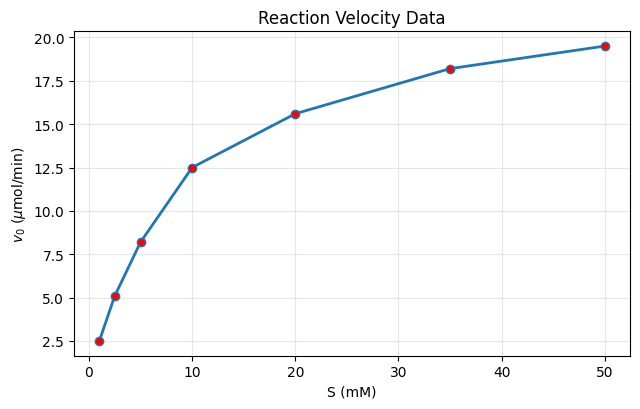

In [20]:
## Plot the data set
import matplotlib.pyplot as plt

# Reaction Velocity Data
S  = [1.0, 2.5, 5.0, 10.0, 20.0, 35.0, 50.0]   # mM
v0 = [2.5, 5.1, 8.2, 12.5, 15.6, 18.2, 19.5]   # umol/min

# Make a clean, publication-friendly figure
fig, ax = plt.subplots(figsize=(6.5, 4.2))  # "good shape" for a PDF
ax.plot(S, v0, marker='o', linewidth=2, markersize=6, markerfacecolor='red')
ax.set_xlabel('S (mM)')
ax.set_ylabel(r'$v_0$ ($\mu$mol/min)')
ax.set_title('Reaction Velocity Data')
ax.grid(True, alpha=0.3)

fig.tight_layout()

# Save as vector PDF (crisp at any zoom)
fig.savefig("reaction_velocity.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [21]:
### Implementing the Gauss-Newton method to solve the nonlinear least-squares problem.
import numpy as np
X_train = np.array([1.0, 2.5, 5.0, 10.0, 20.0, 35.0, 50.0])   # mM
y_train = np.array([2.5, 5.1, 8.2, 12.5, 15.6, 18.2, 19.5])   # umol/min

def model_residual_eval2(X, y, beta):
    """
    Evaluating the Michaelis–Menten model:
        vhat(S) = Vmax*S/(Km + S)
    Returns:
        F : (m,) model values at each S
    """
    Vmax, Km = beta
    S = np.asarray(X)  # Forces list to become a NumPy array
    v_hat = Vmax * S / (Km + S)
    return v_hat - y   # Assuming this is a residual function

def model_jacobian_eval2(X, y, beta):
    """
    Evaluating the Jacobian of the Michaelis–Menten model:
        vhat(S) = Vmax*S/(Km + S)
    Returns:
        dF : (m,2) Jacobian w.r.t. (Vmax, Km)
    """
    S = np.asarray(X)
    Vmax, Km = beta
    denom = Km + S
    pd_Vmax = S / denom
    pd_Km = - (Vmax * S) / (denom**2)
    return np.column_stack((pd_Vmax, pd_Km))

# *** Call the solver ***
beta0 = np.array([0.0, 0.0])  # initial guess [beta0, beta1]
beta_best, info = gauss_newton(model_residual_eval2, model_jacobian_eval2, X_train, y_train, beta0, max_iter=100, rtol=1e-7, verbose=True)

# *** Print out the results ***
print("\nEstimated parameters:", beta_best)
print("Converged:", info["converged"])
print("Iterations:", info["n_iter"])
print("Final ||J^T r||:", info["grad_norm"][-1] if info["grad_norm"] else None)
print("Final ||r||:", info["res_norm"][-1] if info["res_norm"] else None)


Iter 000 | ||J^T r||=8.160e+01 | ||r/r0||=4.264e-01 | ||d||=1.166e+01
Iter 001 | ||J^T r||=1.381e+02 | ||r/r0||=1.974e-01 | ||d||=4.269e+00
Iter 002 | ||J^T r||=3.197e+01 | ||r/r0||=1.166e-01 | ||d||=4.378e+00
Iter 003 | ||J^T r||=7.067e+00 | ||r/r0||=5.283e-02 | ||d||=3.904e+00
Iter 004 | ||J^T r||=1.405e+00 | ||r/r0||=1.564e-02 | ||d||=1.682e+00
Iter 005 | ||J^T r||=1.453e-01 | ||r/r0||=5.957e-03 | ||d||=2.085e-01
Iter 006 | ||J^T r||=2.411e-03 | ||r/r0||=5.747e-03 | ||d||=4.060e-03
Iter 007 | ||J^T r||=1.033e-05 | ||r/r0||=5.747e-03 | ||d||=2.953e-05
Iter 008 | ||J^T r||=6.720e-08 | ||r/r0||=5.747e-03 | ||d||=1.974e-07
>>> Convergence achieved!

Estimated parameters: [22.70782954  8.59958244]
Converged: True
Iterations: 9
Final ||J^T r||: 6.719888348775562e-08
Final ||r||: 0.4689255217321163
